In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import gzip

In [19]:
cols = ['chr', 'start', 'stop', 'score', 'str1', 'str2']

# unzipping + reading the file
dtypes = {'chr': str, 'start': int, 'stop': int, 'score': str, 'str1': str, 'str2': str}
with gzip.open('query.bed.gz', 'rt') as f:
    df = pd.read_csv(f, sep='\t', names=cols, header=None, dtype=dtypes)

df.head()


,chr,start,stop,score,str1,str2
0,chr10,32795245,32795315,70,.,+
1,chr11,95864728,95864770,42,.,+
2,chr16,32027808,32027880,72,.,+
3,chr4,76608451,76608515,64,.,+
4,chr18,45847777,45847816,39,.,-


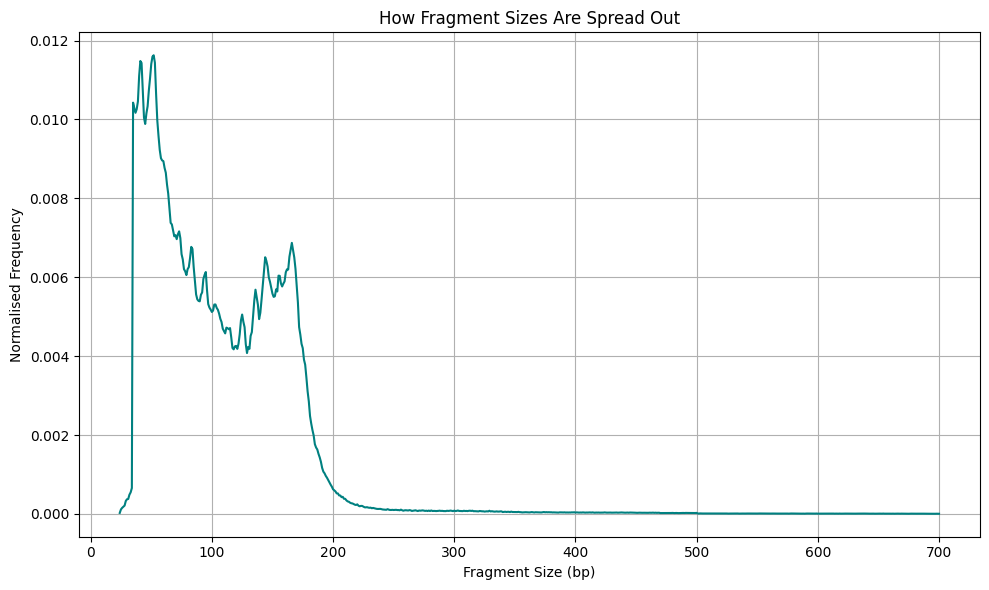

In [20]:

# calculating the length of each chunk
# subtract start from stop to get length in base pairs
df['len'] = df['stop'] - df['start']


# calculating the freq of each length (basically counting how many times each length shows up)

# value_counts to get how many of each length, then sort it so it x-axis in plot is arranged
len_counts = df['len'].value_counts().sort_index()

# normalising the count (between 0 and 1)
# makes things comparable by turning into relative frequencies
len_freq = len_counts / len_counts.sum()

# plot the graph

plt.figure(figsize=(10, 6))
plt.plot(len_freq.index, len_freq.values, color='teal')
plt.xlabel("Fragment Size (bp)")
plt.ylabel("Normalised Frequency")
plt.title("How Fragment Sizes Are Spread Out")
plt.grid(True)
plt.tight_layout()
plt.show()


In summary, we took in the bed file, got the length of each DNA piece, figured out how many there are of each size, normalized that to a scale from 0 to 1,and plotted it to see what the spread looks like. Now, we're gonna rescale the dataset to match reference distribution

In [21]:
# reading reference size distribution
ref = pd.read_csv('reference.hist', sep='\t', header=None, names=['len', 'freq'])

# multiply the ref freq by our total count so we know how many we want of each

# total
total_fragments = len(df)
target = (ref['freq'] * total_fragments).astype(int)
# making sure it's indexed by length
target.index = ref['len']



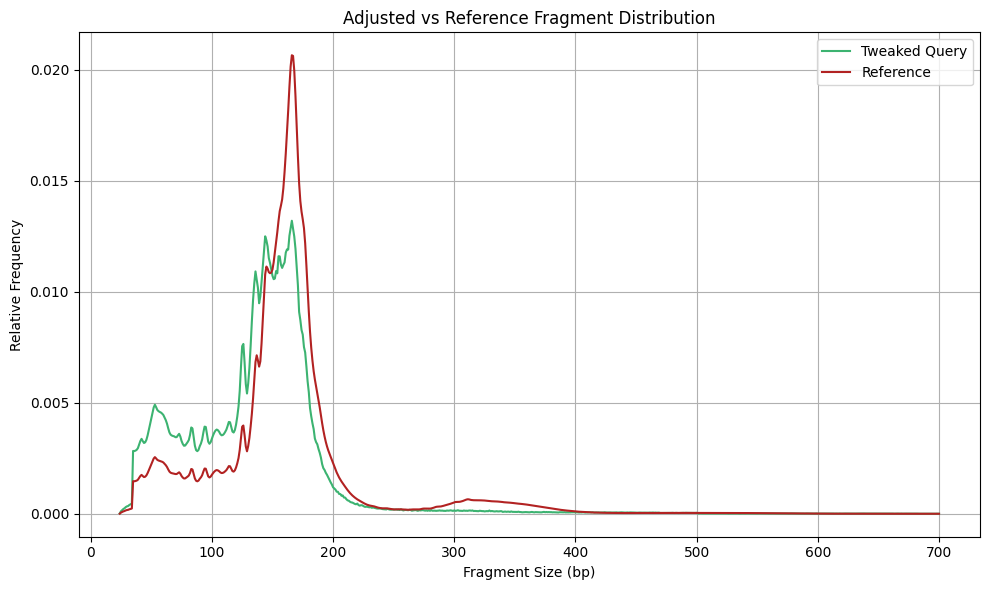

In [22]:
# randomly selecting the right number of fragments from query data for each length

groups = df.groupby('len')
bits = []

for l, cnt in target.items():
    if l in groups.groups:
        bunch = groups.get_group(l)
        # grab as many as we can (or all if we don’t find enough)
        if len(bunch) >= cnt:
            pick = bunch.sample(n=cnt, random_state=42)
        else:
            pick = bunch
        bits.append(pick)

# stack everything into one DataFrame
resampled = pd.concat(bits, ignore_index=True)

# checking if the new version looks like the reference

# get and normalize new distribution
resampled_counts = resampled['len'].value_counts().sort_index()
resampled_freq = resampled_counts / resampled_counts.sum()

# draw both side-by-side
plt.figure(figsize=(10, 6))
plt.plot(resampled_freq.index, resampled_freq.values, label='Tweaked Query', color='mediumseagreen')
plt.plot(ref['len'], ref['freq'], label='Reference', color='firebrick')
plt.xlabel("Fragment Size (bp)")
plt.ylabel("Relative Frequency")
plt.title("Adjusted vs Reference Fragment Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



#Final Summary
We took our original data and reworked it to look like a given reference. This was done by calculating how many of each size we need, then sampling from what we have. The result should now mirror the reference distribution pretty closely.
